# Notebook 02 — EDA and Business Insights

Freddie Mac Single Family Loan-Level Dataset, 2019 origination-vintage sample.

This notebook consumes the leakage-safe modelling table and the separate label-diagnostic table produced by notebook 01. It profiles portfolio composition, observed default associations, interactions, geography, timing, default dynamics, and target sensitivity.

The analysis is descriptive: observed segment differences do not by themselves establish causal mechanisms. Figures are saved to `figures/` for reuse in the case study.

## 0. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid")

cwd = Path.cwd().resolve()
if (cwd / "pyproject.toml").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "pyproject.toml").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise RuntimeError(f"Could not resolve project root from {cwd}")

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

LOANS_FILE = DATA_PROCESSED / "loans_2019_labeled.parquet"
DIAGNOSTICS_FILE = DATA_PROCESSED / "label_diagnostics_2019.parquet"
assert LOANS_FILE.exists(), f"Missing {LOANS_FILE}; run notebook 01 first"
assert DIAGNOSTICS_FILE.exists(), f"Missing {DIAGNOSTICS_FILE}; run notebook 01 first"

SEED = 42

loans_model = pd.read_parquet(LOANS_FILE)
label_diagnostics = pd.read_parquet(DIAGNOSTICS_FILE)

POST_ORIGINATION_COLUMNS = {
    "max_dpd_24m", "observation_months",
    "last_reporting_period_24m", "prepaid_within_24m",
}
assert not POST_ORIGINATION_COLUMNS.intersection(loans_model.columns)
assert loans_model["loan_sequence_number"].is_unique
assert label_diagnostics["loan_sequence_number"].is_unique

# Enriched table used only for EDA. Downstream models must use loans_model.
diagnostic_features = label_diagnostics.drop(columns="default_24m")
loans = loans_model.merge(
    diagnostic_features,
    on="loan_sequence_number",
    how="left",
    validate="one_to_one",
)

print(f"Modelling table: {loans_model.shape[0]:,} rows × {loans_model.shape[1]} columns")
print(f"EDA table with diagnostics: {loans.shape[0]:,} rows × {loans.shape[1]} columns")
print(f"Corrected default rate: {loans['default_24m'].mean() * 100:.3f} %")
print("Leakage guard: diagnostic columns are absent from the modelling table.")

Modelling table: 49,946 rows × 20 columns
EDA table with diagnostics: 49,946 rows × 24 columns
Corrected default rate: 4.589 %
Leakage guard: diagnostic columns are absent from the modelling table.


## 1. Context and objectives

The modelling population contains 49,946 in-scope loans and uses a calendar-corrected target: `default_24m = 1` when a loan records 90+ DPD during calendar months 0–24. The corrected observed rate is approximately 4.59%.

The objective is to identify descriptive risk patterns and modelling hypotheses. Segment rates are accompanied by counts and binomial confidence intervals where practical. Mechanistic explanations are treated as hypotheses until they survive multivariable analysis.

## 2. Portfolio overview

### 2.1 Headline numbers

In [2]:
# Headline metrics
n_loans = len(loans)
total_upb = loans["original_upb"].sum()
avg_upb = loans["original_upb"].mean()
default_rate = loans["default_24m"].mean()
n_states = loans["property_state"].nunique()

# Date range: convert YYYYMM to a readable label without touching the loans table
fpd_min = pd.to_datetime(loans["first_payment_date"].min(), format="%Y%m").strftime("%b %Y")
fpd_max = pd.to_datetime(loans["first_payment_date"].max(), format="%Y%m").strftime("%b %Y")

print(f"Loans:            {n_loans:>12,}")
print(f"Total UPB:        {total_upb / 1e9:>12.2f} B$")
print(f"Average UPB:      {avg_upb / 1e3:>12.1f} k$")
print(f"Default rate:     {default_rate * 100:>12.2f} %")
print(f"First payment:    {fpd_min:>12} to {fpd_max}")
print(f"States covered:   {n_states:>12}")


Loans:                  49,946
Total UPB:               12.71 B$
Average UPB:             254.5 k$
Default rate:             4.59 %
First payment:        Feb 2019 to Mar 2020
States covered:             54


**Takeaway.** The supplied sample contains almost 50k loans and $12.7B of original balance. These figures characterize the sample, not necessarily the complete Freddie Mac 2019 vintage. Its performance horizon overlaps the COVID period, so the observed target reflects both origination characteristics and the subsequent macro-policy environment.

### 2.2 Origination timing and observation window

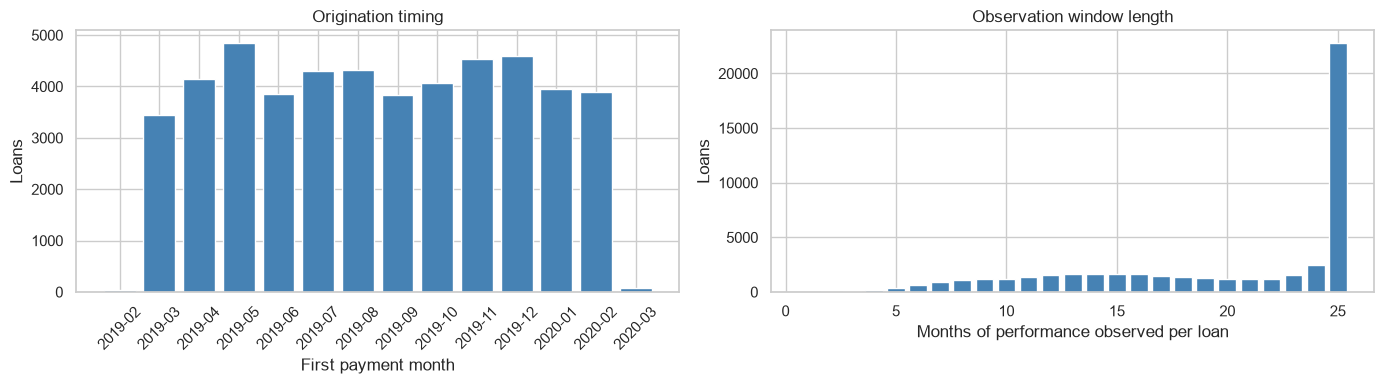

In [3]:
# Local datetime version of first_payment_date, for plotting only
fpd = pd.to_datetime(loans["first_payment_date"], format="%Y%m")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: origination timing (via first_payment_date)
fpd_counts = fpd.dt.to_period("M").value_counts().sort_index()
axes[0].bar(fpd_counts.index.astype(str), fpd_counts.values, color="steelblue")
axes[0].set_title("Origination timing")
axes[0].set_xlabel("First payment month")
axes[0].set_ylabel("Loans")
axes[0].tick_params(axis="x", rotation=45)

# Right: observation window length
obs_counts = loans["observation_months"].value_counts().sort_index()
axes[1].bar(obs_counts.index.astype(int), obs_counts.values, color="steelblue")
axes[1].set_title("Observation window length")
axes[1].set_xlabel("Months of performance observed per loan")
axes[1].set_ylabel("Loans")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_portfolio_overview_timing.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway.** First-payment dates cover February 2019 through March 2020. About 46% of loans have all 25 reporting months inside the horizon; most shorter histories end through voluntary payoff. Prepayment is a competing terminal event: after payoff, the mortgage is no longer exposed to default. `observation_months` is useful for audit but is never an origination-time predictor.

### 2.3 Loan purpose mix

In [4]:
purpose_labels = {"P": "Purchase", "C": "Cash-out refi", "N": "Rate-term refi"}

purpose_summary = (
    loans.groupby("loan_purpose")
    .agg(count=("loan_sequence_number", "size"), avg_upb=("original_upb", "mean"))
    .reset_index()
)
purpose_summary["loan_purpose"] = purpose_summary["loan_purpose"].map(purpose_labels)
purpose_summary["share"] = purpose_summary["count"] / purpose_summary["count"].sum()
purpose_summary = (
    purpose_summary[["loan_purpose", "count", "share", "avg_upb"]]
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

# Format for display
purpose_summary_display = purpose_summary.copy()
purpose_summary_display["count"] = purpose_summary_display["count"].map("{:,}".format)
purpose_summary_display["share"] = purpose_summary_display["share"].map("{:.1%}".format)
purpose_summary_display["avg_upb"] = purpose_summary_display["avg_upb"].map("{:,.0f} $".format)

purpose_summary_display

,loan_purpose,count,share,avg_upb
0,Purchase,"27,763",55.6%,"251,983 $"
1,Rate-term refi,"11,614",23.3%,"281,831 $"
2,Cash-out refi,"10,569",21.2%,"231,139 $"


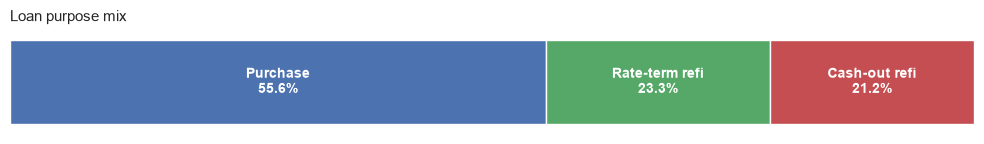

In [5]:
# Stacked horizontal bar showing the purpose mix in a single row
fig, ax = plt.subplots(figsize=(10, 1.6))

colors = {"Purchase": "#4C72B0", "Rate-term refi": "#55A868", "Cash-out refi": "#C44E52"}

left = 0
for _, row in purpose_summary.iterrows():
    label = row["loan_purpose"]
    share = row["share"]
    ax.barh(0, share, left=left, color=colors[label], edgecolor="white", linewidth=1)
    # In-bar label: name and share
    ax.text(left + share / 2, 0, f"{label}\n{share:.1%}",
            ha="center", va="center", color="white", fontsize=10, fontweight="bold")
    left += share

ax.set_xlim(0, 1)
ax.set_ylim(-0.5, 0.5)
ax.set_yticks([])
ax.set_xticks([])
ax.set_title("Loan purpose mix", loc="left", fontsize=11)
for spine in ax.spines.values():
    spine.set_visible(False)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_portfolio_overview_purpose_mix.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway.** Purchase loans dominate the vintage at 55.6 % of volume, consistent with Freddie Mac's role as a GSE buyer of new-purchase mortgages. Refinances split roughly evenly between rate-term (23.3 %) and cash-out (21.2 %), reflecting the falling-rate environment of 2019 that made rate-term refis attractive. Cash-out refis carry the smallest average ticket at $231k, below purchase ($252k) and rate-term ($282k), a first hint that this segment sits on a lower-value property base. Whether this segment also carries higher default risk is the subject of section 3.4.

## 3. Univariate risk analysis

Each subsection reports segment volume, observed default rate, and uncertainty. A dashed line marks the sample-wide rate. The comparisons are unadjusted: differences may reflect correlated borrower, collateral, geographic, or channel characteristics.

In [6]:

def binomial_summary(df, group_col, target="default_24m", z=1.96):
    """Counts, event rates, and Wilson 95% intervals by group."""
    out = (
        df.groupby(group_col, observed=True, dropna=False)[target]
        .agg(count="size", defaults="sum", default_rate="mean")
    )
    n = out["count"].astype(float)
    p = out["default_rate"].astype(float)
    denominator = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denominator
    margin = z * np.sqrt((p * (1 - p) / n) + z**2 / (4 * n**2)) / denominator
    out["ci_low"] = (centre - margin).clip(0, 1)
    out["ci_high"] = (centre + margin).clip(0, 1)
    return out


### 3.1 Credit dimension: FICO score

In [7]:
fico_bins = [-np.inf, 619, 659, 699, 739, 779, np.inf]
fico_labels = ["<620", "620-659", "660-699", "700-739", "740-779", "780+"]

fico_band = pd.cut(loans["credit_score"], bins=fico_bins, labels=fico_labels)
fico_band = fico_band.cat.add_categories("Missing").fillna("Missing")

fico_stats = binomial_summary(
    loans.assign(fico_band=fico_band), "fico_band"
).reindex(fico_labels + ["Missing"])

print(fico_stats.assign(
    count=lambda d: d["count"].map("{:,}".format),
    defaults=lambda d: d["defaults"].map("{:,}".format),
    default_rate=lambda d: (d["default_rate"] * 100).map("{:.2f} %".format),
    ci=lambda d: [f"[{lo*100:.2f}, {hi*100:.2f}] %" for lo, hi in zip(d.ci_low, d.ci_high)],
)[["count", "defaults", "default_rate", "ci"]])

            count defaults default_rate                ci
fico_band                                                
<620           36        3       8.33 %   [2.87, 21.83] %
620-659     1,816      218      12.00 %  [10.59, 13.58] %
660-699     5,622      471       8.38 %    [7.68, 9.13] %
700-739    11,056      712       6.44 %    [6.00, 6.91] %
740-779    16,163      628       3.89 %    [3.60, 4.19] %
780+       15,235      259       1.70 %    [1.51, 1.92] %
Missing        18        1       5.56 %   [0.99, 25.76] %


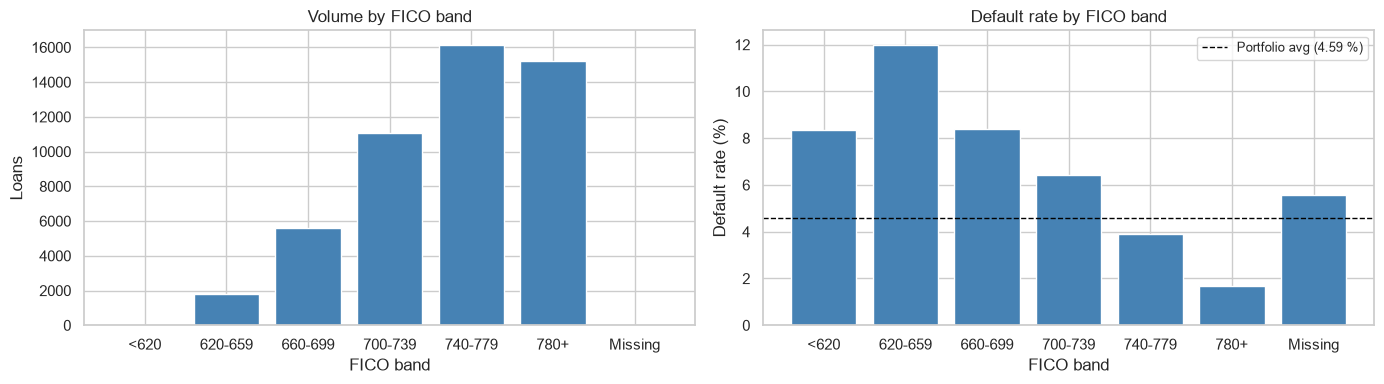

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: volume by FICO band
axes[0].bar(fico_stats.index.astype(str), fico_stats["count"], color="steelblue")
axes[0].set_title("Volume by FICO band")
axes[0].set_xlabel("FICO band")
axes[0].set_ylabel("Loans")
axes[0].tick_params(axis="x", rotation=0)

# Right: default rate by FICO band
axes[1].bar(fico_stats.index.astype(str), fico_stats["default_rate"] * 100, color="steelblue")
axes[1].axhline(default_rate * 100, color="black", linestyle="--", linewidth=1,
                label=f"Portfolio avg ({default_rate * 100:.2f} %)")
axes[1].set_title("Default rate by FICO band")
axes[1].set_xlabel("FICO band")
axes[1].set_ylabel("Default rate (%)")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(loc="upper right", fontsize=9)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_univariate_fico.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway.** FICO has the strongest univariate gradient in this EDA: observed rates fall from 12.28% in 620–659 to about 1.7% in 780+. The `<620` and Missing groups contain fewer than 40 loans and are not interpretable. This pattern makes FICO a strong modelling candidate, while its independent contribution must still be assessed jointly with leverage and affordability.

### 3.2 Leverage dimension: LTV and OCLTV

In [9]:
loans_ltv = loans.dropna(subset=["ltv"])
n_missing_ltv = len(loans) - len(loans_ltv)

ltv_bins = [-np.inf, 60, 70, 80, 85, 90, 95, np.inf]
ltv_labels = ["<=60", "60-70", "70-80", "80-85", "85-90", "90-95", ">95"]
ltv_band = pd.cut(loans_ltv["ltv"], bins=ltv_bins, labels=ltv_labels)

ltv_stats = binomial_summary(
    loans_ltv.assign(ltv_band=ltv_band), "ltv_band"
).reindex(ltv_labels)

print(f"Loans with missing LTV excluded: {n_missing_ltv}")
print(ltv_stats.assign(
    count=lambda d: d["count"].map("{:,}".format),
    defaults=lambda d: d["defaults"].map("{:,}".format),
    default_rate=lambda d: (d["default_rate"] * 100).map("{:.2f} %".format),
    ci=lambda d: [f"[{lo*100:.2f}, {hi*100:.2f}] %" for lo, hi in zip(d.ci_low, d.ci_high)],
)[["count", "defaults", "default_rate", "ci"]])

Loans with missing LTV excluded: 0
           count defaults default_rate              ci
ltv_band                                              
<=60       8,938      262       2.93 %  [2.60, 3.30] %
60-70      5,586      234       4.19 %  [3.69, 4.75] %
70-80     19,223      807       4.20 %  [3.92, 4.49] %
80-85      2,192      106       4.84 %  [4.01, 5.82] %
85-90      4,278      228       5.33 %  [4.70, 6.04] %
90-95      7,522      484       6.43 %  [5.90, 7.01] %
>95        2,207      171       7.75 %  [6.70, 8.94] %


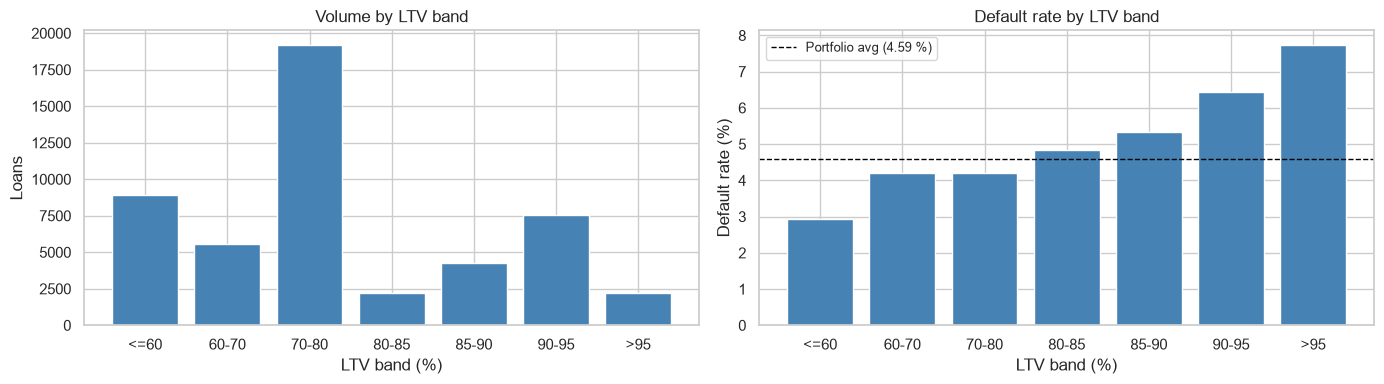

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: volume by LTV band
axes[0].bar(ltv_stats.index.astype(str), ltv_stats["count"], color="steelblue")
axes[0].set_title("Volume by LTV band")
axes[0].set_xlabel("LTV band (%)")
axes[0].set_ylabel("Loans")
axes[0].tick_params(axis="x", rotation=0)

# Right: default rate by LTV band
axes[1].bar(ltv_stats.index.astype(str), ltv_stats["default_rate"] * 100, color="steelblue")
axes[1].axhline(default_rate * 100, color="black", linestyle="--", linewidth=1,
                label=f"Portfolio avg ({default_rate * 100:.2f} %)")
axes[1].set_title("Default rate by LTV band")
axes[1].set_xlabel("LTV band (%)")
axes[1].set_ylabel("Default rate (%)")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(loc="upper left", fontsize=9)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_univariate_ltv.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway.** Observed default risk rises consistently across the chosen LTV bands, from roughly 2.9% at `<=60` to about 7.9% above 95. The volume peaks around common mortgage-program thresholds. The step around 80% is compatible with borrower selection and mortgage-insurance rules, but this descriptive view does not isolate either mechanism.

### 3.3 Affordability dimension: DTI

In [11]:
loans_dti = loans.dropna(subset=["dti"])
n_missing_dti = len(loans) - len(loans_dti)

dti_bins = [-np.inf, 30, 36, 43, 45, np.inf]
dti_labels = ["<=30", "30-36", "36-43", "43-45", ">45"]
dti_band = pd.cut(loans_dti["dti"], bins=dti_bins, labels=dti_labels)

dti_stats = binomial_summary(
    loans_dti.assign(dti_band=dti_band), "dti_band"
).reindex(dti_labels)

print(f"Loans with missing DTI excluded: {n_missing_dti}")
print(dti_stats.assign(
    count=lambda d: d["count"].map("{:,}".format),
    defaults=lambda d: d["defaults"].map("{:,}".format),
    default_rate=lambda d: (d["default_rate"] * 100).map("{:.2f} %".format),
    ci=lambda d: [f"[{lo*100:.2f}, {hi*100:.2f}] %" for lo, hi in zip(d.ci_low, d.ci_high)],
)[["count", "defaults", "default_rate", "ci"]])

Loans with missing DTI excluded: 31
           count defaults default_rate              ci
dti_band                                              
<=30      14,960      340       2.27 %  [2.05, 2.52] %
30-36      9,854      390       3.96 %  [3.59, 4.36] %
36-43     13,809      763       5.53 %  [5.16, 5.92] %
43-45      4,727      373       7.89 %  [7.16, 8.69] %
>45        6,565      422       6.43 %  [5.86, 7.05] %


**Takeaway.** DTI rises strongly through the 43–45% band and then reverses above 45%. The pattern is compatible with selection through compensating factors, but this cannot be established from the unadjusted table alone. The non-monotonic shape should be tested in a multivariable model rather than imposed as a causal underwriting rule.

### 3.4 Loan characteristics: purpose, occupancy, channel

                 count defaults default_rate  ci_low  ci_high
purpose_named                                                
Purchase        27,763    1,305       4.70 %    0.04     0.05
Rate-term refi  11,614      471       4.06 %    0.04     0.04
Cash-out refi   10,569      516       4.88 %    0.04     0.05


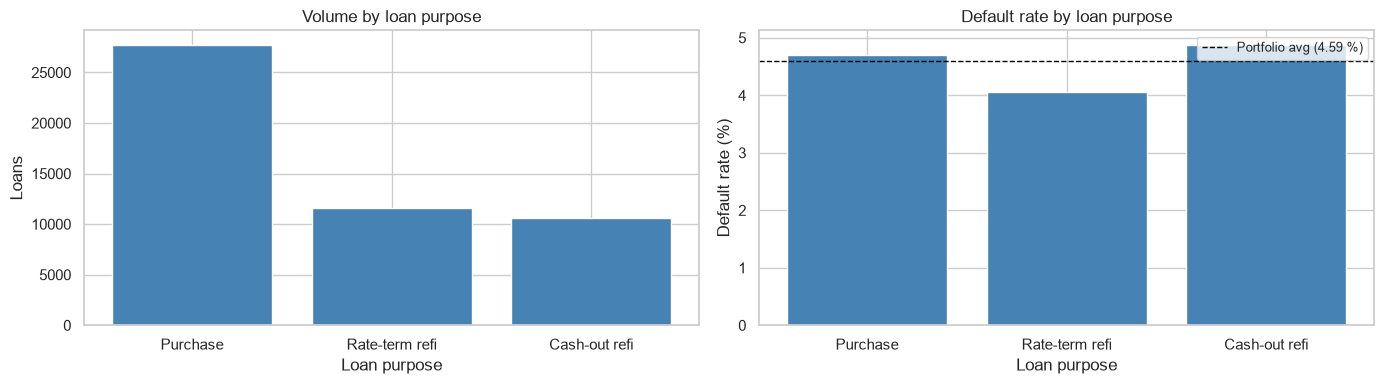

In [12]:
purpose_labels = {"P": "Purchase", "C": "Cash-out refi", "N": "Rate-term refi"}

purpose_stats = binomial_summary(
    loans.assign(purpose_named=loans["loan_purpose"].map(purpose_labels)), "purpose_named"
).sort_values("count", ascending=False)

print(purpose_stats.assign(
    count=lambda d: d["count"].map("{:,}".format),
    defaults=lambda d: d["defaults"].map("{:,}".format),
    default_rate=lambda d: (d["default_rate"] * 100).map("{:.2f} %".format),
)[["count", "defaults", "default_rate", "ci_low", "ci_high"]])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(purpose_stats.index, purpose_stats["count"], color="steelblue")
axes[0].set_title("Volume by loan purpose")
axes[0].set_xlabel("Loan purpose")
axes[0].set_ylabel("Loans")

axes[1].bar(purpose_stats.index, purpose_stats["default_rate"] * 100, color="steelblue")
axes[1].axhline(default_rate * 100, color="black", linestyle="--", linewidth=1,
                label=f"Portfolio avg ({default_rate * 100:.2f} %)")
axes[1].set_title("Default rate by loan purpose")
axes[1].set_xlabel("Loan purpose")
axes[1].set_ylabel("Default rate (%)")
axes[1].legend(loc="upper right", fontsize=9)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_univariate_purpose.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway.** Loan purpose is a secondary univariate signal: rate-term refinances have the lowest observed rate and cash-out refinances the highest, with a spread below one percentage point. Whether purpose adds information beyond FICO, LTV, DTI, and borrower composition must be evaluated in the model.

                  count defaults default_rate  ci_low  ci_high
occupancy_named                                               
Primary          44,549    2,047       4.59 %    0.04     0.05
Investment        3,420      174       5.09 %    0.04     0.06
Second home       1,977       71       3.59 %    0.03     0.05


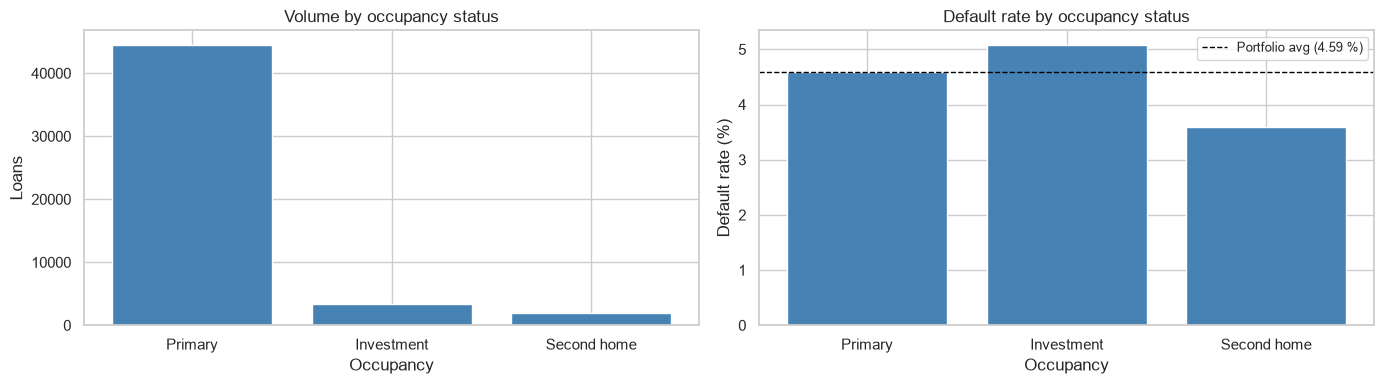

In [13]:
occupancy_labels = {"P": "Primary", "S": "Second home", "I": "Investment"}

occupancy_stats = binomial_summary(
    loans.assign(occupancy_named=loans["occupancy_status"].map(occupancy_labels)), "occupancy_named"
).sort_values("count", ascending=False)

print(occupancy_stats.assign(
    count=lambda d: d["count"].map("{:,}".format),
    defaults=lambda d: d["defaults"].map("{:,}".format),
    default_rate=lambda d: (d["default_rate"] * 100).map("{:.2f} %".format),
)[["count", "defaults", "default_rate", "ci_low", "ci_high"]])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(occupancy_stats.index, occupancy_stats["count"], color="steelblue")
axes[0].set_title("Volume by occupancy status")
axes[0].set_xlabel("Occupancy")
axes[0].set_ylabel("Loans")

axes[1].bar(occupancy_stats.index, occupancy_stats["default_rate"] * 100, color="steelblue")
axes[1].axhline(default_rate * 100, color="black", linestyle="--", linewidth=1,
                label=f"Portfolio avg ({default_rate * 100:.2f} %)")
axes[1].set_title("Default rate by occupancy status")
axes[1].set_xlabel("Occupancy")
axes[1].set_ylabel("Default rate (%)")
axes[1].legend(loc="upper right", fontsize=9)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_univariate_occupancy.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway.** Investment properties show a somewhat higher observed rate than primary residences, while second homes are lower in this sample. These differences are compatible with underwriting selection and borrower mix; the EDA does not establish a behavioral mechanism.

                count defaults default_rate  ci_low  ci_high
channel_named                                               
Retail         26,034    1,042       4.00 %    0.04     0.04
Correspondent  17,789      964       5.42 %    0.05     0.06
Broker          6,123      286       4.67 %    0.04     0.05


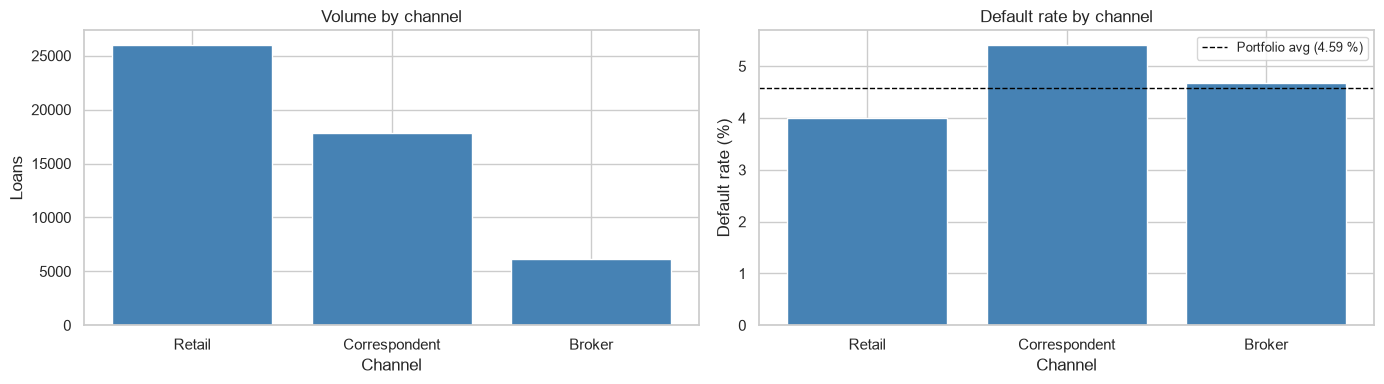

In [14]:
channel_labels = {"R": "Retail", "B": "Broker", "C": "Correspondent", "T": "TPO not specified"}

channel_stats = binomial_summary(
    loans.assign(channel_named=loans["channel"].map(channel_labels)), "channel_named"
).sort_values("count", ascending=False)

print(channel_stats.assign(
    count=lambda d: d["count"].map("{:,}".format),
    defaults=lambda d: d["defaults"].map("{:,}".format),
    default_rate=lambda d: (d["default_rate"] * 100).map("{:.2f} %".format),
)[["count", "defaults", "default_rate", "ci_low", "ci_high"]])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(channel_stats.index, channel_stats["count"], color="steelblue")
axes[0].set_title("Volume by channel")
axes[0].set_xlabel("Channel")
axes[0].set_ylabel("Loans")

axes[1].bar(channel_stats.index, channel_stats["default_rate"] * 100, color="steelblue")
axes[1].axhline(default_rate * 100, color="black", linestyle="--", linewidth=1,
                label=f"Portfolio avg ({default_rate * 100:.2f} %)")
axes[1].set_title("Default rate by channel")
axes[1].set_xlabel("Channel")
axes[1].set_ylabel("Default rate (%)")
axes[1].legend(loc="upper right", fontsize=9)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_univariate_channel.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway.** Correspondent loans have the highest observed rate and retail loans the lowest. Channel may proxy for differences in borrower and collateral mix, so its independent contribution should be assessed after adjustment rather than inferred from this univariate comparison.

### 3.5 Property characteristics: property type, units, borrowers

                       count default_rate
pt_named                                 
Single Family         31,357       4.65 %
PUD                   14,221       4.25 %
Condo                  4,094       5.35 %
Manufactured Housing     197       4.57 %
Cooperative               77       3.90 %


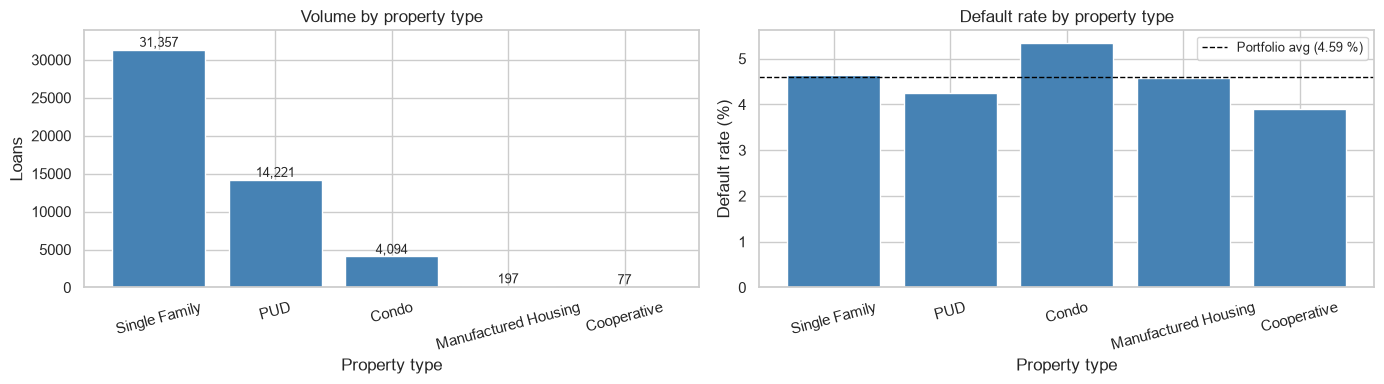

In [15]:
property_type_labels = {
    "SF": "Single Family",
    "CO": "Condo",
    "PU": "PUD",
    "MH": "Manufactured Housing",
    "CP": "Cooperative",
    "LH": "Leasehold",
}

pt_stats = (
    loans.assign(pt_named=loans["property_type"].map(property_type_labels))
    .groupby("pt_named")
    .agg(count=("default_24m", "size"), default_rate=("default_24m", "mean"))
    .sort_values("count", ascending=False)
)

print(pt_stats.assign(
    count=lambda d: d["count"].map("{:,}".format),
    default_rate=lambda d: (d["default_rate"] * 100).map("{:.2f} %".format),
))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(pt_stats.index, pt_stats["count"], color="steelblue")
axes[0].set_title("Volume by property type")
axes[0].set_xlabel("Property type")
axes[0].set_ylabel("Loans")
axes[0].tick_params(axis="x", rotation=15)

for i, v in enumerate(pt_stats["count"]):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)

axes[0].set_ylim(0, pt_stats["count"].max() * 1.08)

axes[1].bar(pt_stats.index, pt_stats["default_rate"] * 100, color="steelblue")
axes[1].axhline(default_rate * 100, color="black", linestyle="--", linewidth=1,
                label=f"Portfolio avg ({default_rate * 100:.2f} %)")
axes[1].set_title("Default rate by property type")
axes[1].set_xlabel("Property type")
axes[1].set_ylabel("Default rate (%)")
axes[1].tick_params(axis="x", rotation=15)
axes[1].legend(loc="upper right", fontsize=9)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_univariate_property_type.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway.** Condo loans have a higher observed rate than the two largest comparison groups, while manufactured housing and cooperatives are too sparse for reliable conclusions. Property type remains a plausible secondary feature; explanations involving fees, liquidity, or borrower composition are hypotheses rather than demonstrated mechanisms.

Loans with missing num_units excluded from this view: 0
                count default_rate
num_units_int                     
1              48,888       4.52 %
2                 765       6.80 %
3                 174      11.49 %
4                 119       8.40 %


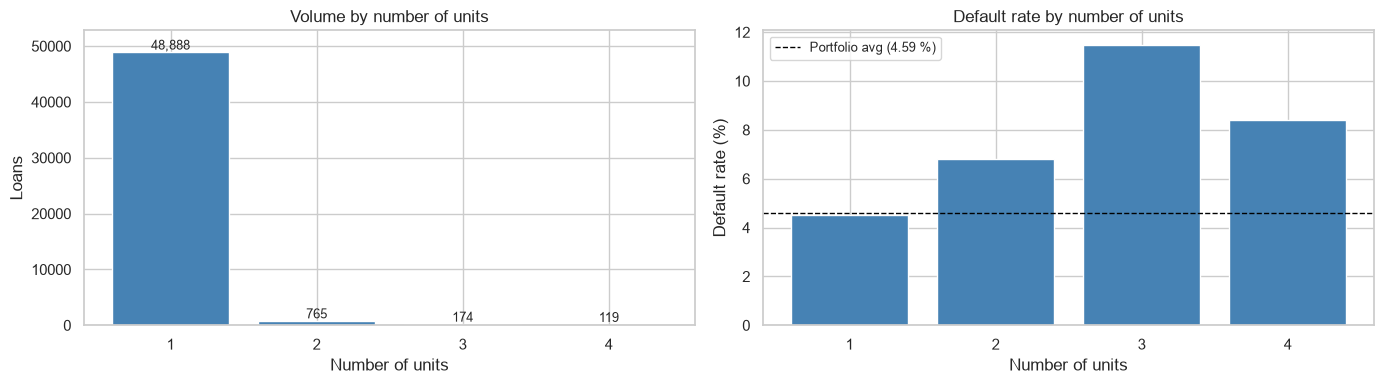

In [16]:
loans_units = loans.dropna(subset=["num_units"]).copy()
loans_units["num_units_int"] = loans_units["num_units"].astype(int)
n_missing_units = len(loans) - len(loans_units)

units_stats = (
    loans_units.groupby("num_units_int")
    .agg(count=("default_24m", "size"), default_rate=("default_24m", "mean"))
    .sort_index()
)

print(f"Loans with missing num_units excluded from this view: {n_missing_units}")
print(units_stats.assign(
    count=lambda d: d["count"].map("{:,}".format),
    default_rate=lambda d: (d["default_rate"] * 100).map("{:.2f} %".format),
))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(units_stats.index.astype(str), units_stats["count"], color="steelblue")
axes[0].set_title("Volume by number of units")
axes[0].set_xlabel("Number of units")
axes[0].set_ylabel("Loans")

# Value labels for readability (same reasoning as property type)
for i, v in enumerate(units_stats["count"]):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
axes[0].set_ylim(0, units_stats["count"].max() * 1.08)

axes[1].bar(units_stats.index.astype(str), units_stats["default_rate"] * 100, color="steelblue")
axes[1].axhline(default_rate * 100, color="black", linestyle="--", linewidth=1,
                label=f"Portfolio avg ({default_rate * 100:.2f} %)")
axes[1].set_title("Default rate by number of units")
axes[1].set_xlabel("Number of units")
axes[1].set_ylabel("Default rate (%)")
axes[1].legend(loc="upper left", fontsize=9)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_univariate_num_units.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway.** Multi-unit loans show higher observed rates than one-unit loans, but the 3- and 4-unit groups are small and their ordering is uncertain. A binary one-unit versus multi-unit feature is a reasonable modelling candidate, subject to out-of-sample validation.

Loans with missing number_of_borrowers excluded from this view: 0
              count default_rate
nb_borr_int                     
1            26,924       5.42 %
2            22,524       3.55 %
3               451       5.99 %
4                46      10.87 %
5                 1       0.00 %


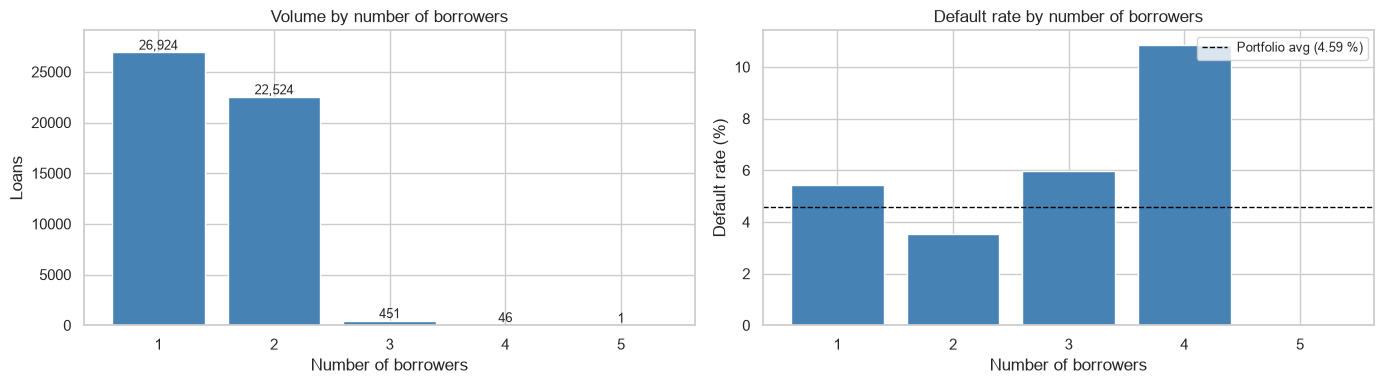

In [17]:
loans_borr = loans.dropna(subset=["number_of_borrowers"]).copy()
loans_borr["nb_borr_int"] = loans_borr["number_of_borrowers"].astype(int)
n_missing_borr = len(loans) - len(loans_borr)

borr_stats = (
    loans_borr.groupby("nb_borr_int")
    .agg(count=("default_24m", "size"), default_rate=("default_24m", "mean"))
    .sort_index()
)

print(f"Loans with missing number_of_borrowers excluded from this view: {n_missing_borr}")
print(borr_stats.assign(
    count=lambda d: d["count"].map("{:,}".format),
    default_rate=lambda d: (d["default_rate"] * 100).map("{:.2f} %".format),
))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(borr_stats.index.astype(str), borr_stats["count"], color="steelblue")
axes[0].set_title("Volume by number of borrowers")
axes[0].set_xlabel("Number of borrowers")
axes[0].set_ylabel("Loans")

for i, v in enumerate(borr_stats["count"]):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
axes[0].set_ylim(0, borr_stats["count"].max() * 1.08)

axes[1].bar(borr_stats.index.astype(str), borr_stats["default_rate"] * 100, color="steelblue")
axes[1].axhline(default_rate * 100, color="black", linestyle="--", linewidth=1,
                label=f"Portfolio avg ({default_rate * 100:.2f} %)")
axes[1].set_title("Default rate by number of borrowers")
axes[1].set_xlabel("Number of borrowers")
axes[1].set_ylabel("Default rate (%)")
axes[1].legend(loc="upper right", fontsize=9)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_univariate_num_borrowers.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway.** The two large groups show a clear descriptive difference: one-borrower loans have a higher observed rate than two-borrower loans. This may reflect income diversification as well as correlated household and loan characteristics. Sparse groups with three or more borrowers should be pooled or regularized.

### 3.6 First-time buyer flag

In [18]:
ftb_labels = {"Y": "First-time buyer", "N": "Not first-time"}

ftb_stats = (
    loans.assign(ftb_named=loans["first_time_homebuyer_flag"].map(ftb_labels))
    .groupby("ftb_named", dropna=False)
    .agg(count=("default_24m", "size"), default_rate=("default_24m", "mean"))
)

print("Raw modality distribution (before remap):")
print(loans["first_time_homebuyer_flag"].value_counts(dropna=False))
print("\nAggregated stats:")
print(ftb_stats.assign(
    count=lambda d: d["count"].map("{:,}".format),
    default_rate=lambda d: (d["default_rate"] * 100).map("{:.2f} %".format),
))

Raw modality distribution (before remap):
first_time_homebuyer_flag
N    38691
Y    11255
Name: count, dtype: int64

Aggregated stats:
                   count default_rate
ftb_named                            
First-time buyer  11,255       5.78 %
Not first-time    38,691       4.24 %


In [19]:
purchase_mask = loans["loan_purpose"] == "P"
loans_purchase = loans[purchase_mask]

ftb_stats = binomial_summary(
    loans_purchase.assign(
        ftb_named=loans_purchase["first_time_homebuyer_flag"].map(ftb_labels)
    ),
    "ftb_named",
)

print(f"Purchase loans in sample: {len(loans_purchase):,}")
print(ftb_stats.assign(
    count=lambda d: d["count"].map("{:,}".format),
    defaults=lambda d: d["defaults"].map("{:,}".format),
    default_rate=lambda d: (d["default_rate"] * 100).map("{:.2f} %".format),
)[["count", "defaults", "default_rate", "ci_low", "ci_high"]])

ftb_ltv = (
    loans_purchase.assign(
        ftb_named=loans_purchase["first_time_homebuyer_flag"].map(ftb_labels)
    )
    .groupby("ftb_named")["ltv"]
    .mean()
)
print("\nAverage LTV by group:")
print(ftb_ltv.map("{:.1f} %".format))

Purchase loans in sample: 27,763
                   count defaults default_rate  ci_low  ci_high
ftb_named                                                      
First-time buyer  11,255      650       5.78 %    0.05     0.06
Not first-time    16,508      655       3.97 %    0.04     0.04

Average LTV by group:
ftb_named
First-time buyer    87.0 %
Not first-time      78.6 %
Name: ltv, dtype: str


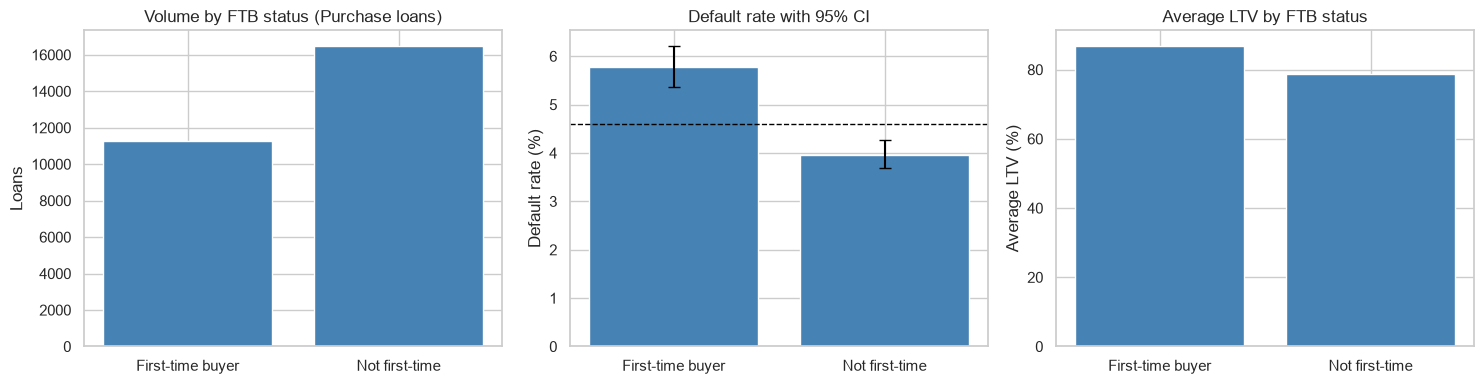

In [20]:
ftb_full = ftb_stats.join(ftb_ltv.rename("avg_ltv"))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(ftb_full.index, ftb_full["count"], color="steelblue")
axes[0].set_title("Volume by FTB status (Purchase loans)")
axes[0].set_ylabel("Loans")

axes[1].bar(ftb_full.index, ftb_full["default_rate"] * 100, color="steelblue")
axes[1].errorbar(
    ftb_full.index,
    ftb_full["default_rate"] * 100,
    yerr=[
        (ftb_full["default_rate"] - ftb_full["ci_low"]) * 100,
        (ftb_full["ci_high"] - ftb_full["default_rate"]) * 100,
    ],
    fmt="none", color="black", capsize=4,
)
axes[1].axhline(default_rate * 100, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Default rate with 95% CI")
axes[1].set_ylabel("Default rate (%)")

axes[2].bar(ftb_full.index, ftb_full["avg_ltv"], color="steelblue")
axes[2].set_title("Average LTV by FTB status")
axes[2].set_ylabel("Average LTV (%)")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_univariate_ftb.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway.** Among purchase loans, first-time buyers have both a higher observed default rate and higher average LTV. This is consistent with leverage explaining part of the association, but a mean-LTV comparison does not prove mediation. The residual contribution of the flag should be tested after controlling for LTV, FICO, DTI, and geography.

## 4. Bivariate risk analysis

Univariate analysis in section 3 quantified each dimension's spread but hides interaction effects. A borrower with FICO 720 and LTV 95 is very different from a borrower with FICO 720 and LTV 60, yet both contribute equally to the FICO 700-739 band average. This section revisits the same three main risk drivers as pairs, to surface the segments where combined weakness or combined strength concentrates the risk. Every cell in the heatmaps that follow shows a default rate; cell size (count) is annotated to prevent reading a rate on a segment too small to be meaningful.

### 4.1 FICO × LTV

Loans excluded (missing FICO or LTV): 18

Default rate (%) by FICO x LTV band:
ltv_band_c   <=70  70-80  80-95   >95
fico_band_c                          
780+         1.08   1.62   2.45  4.28
720-779      3.34   4.14   5.29  6.37
660-719      5.43   7.19   9.95 12.14
<660        10.00  12.52  16.10 18.18

Loan count by FICO x LTV band:
ltv_band_c   <=70  70-80  80-95   >95
fico_band_c                          
780+         5178   6047   3636   374
720-779      5325   8777   6884  1193
660-719      3073   3826   3145   618
<660          940    567    323    22


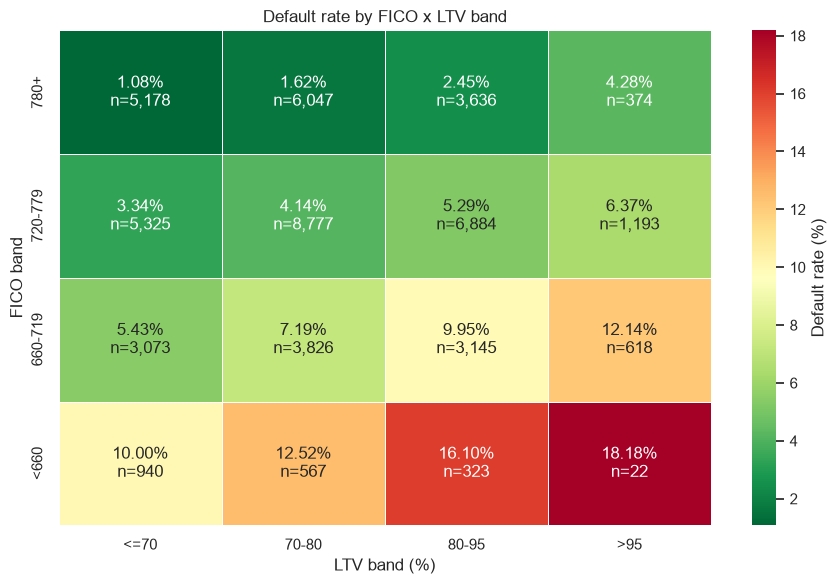

In [21]:
# Restrict to loans with both FICO and LTV populated
loans_fl = loans.dropna(subset=["credit_score", "ltv"]).copy()
n_excluded = len(loans) - len(loans_fl)

# Coarser banding for the heatmap
fico_bins_coarse = [-np.inf, 659, 719, 779, np.inf]
fico_labels_coarse = ["<660", "660-719", "720-779", "780+"]

ltv_bins_coarse = [-np.inf, 70, 80, 95, np.inf]
ltv_labels_coarse = ["<=70", "70-80", "80-95", ">95"]

loans_fl["fico_band_c"] = pd.cut(loans_fl["credit_score"], bins=fico_bins_coarse, labels=fico_labels_coarse)
loans_fl["ltv_band_c"] = pd.cut(loans_fl["ltv"], bins=ltv_bins_coarse, labels=ltv_labels_coarse)

# Pivot: rows = FICO bands (top to bottom = high credit to low), cols = LTV bands (left to right = low leverage to high)
grid_rate = loans_fl.pivot_table(
    index="fico_band_c", columns="ltv_band_c", values="default_24m", aggfunc="mean", observed=True,
) * 100
grid_count = loans_fl.pivot_table(
    index="fico_band_c", columns="ltv_band_c", values="default_24m", aggfunc="size", observed=True,
)

# Reorder rows: top-left = safest (high FICO, low LTV), bottom-right = riskiest (low FICO, high LTV)
grid_rate = grid_rate.reindex(index=fico_labels_coarse[::-1], columns=ltv_labels_coarse)
grid_count = grid_count.reindex(index=fico_labels_coarse[::-1], columns=ltv_labels_coarse)

print(f"Loans excluded (missing FICO or LTV): {n_excluded}")
print("\nDefault rate (%) by FICO x LTV band:")
print(grid_rate.round(2))
print("\nLoan count by FICO x LTV band:")
print(grid_count)

# Build the annotation matrix: default rate on top line, count on second line
annot = grid_rate.copy().astype(object)
for i in range(grid_rate.shape[0]):
    for j in range(grid_rate.shape[1]):
        rate = grid_rate.iat[i, j]
        cnt = grid_count.iat[i, j]
        annot.iat[i, j] = f"{rate:.2f}%\nn={cnt:,}" if pd.notna(rate) else "—"

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    grid_rate, annot=annot, fmt="", cmap="RdYlGn_r",
    cbar_kws={"label": "Default rate (%)"},
    linewidths=0.5, linecolor="white",
    ax=ax,
)
ax.set_title("Default rate by FICO x LTV band")
ax.set_xlabel("LTV band (%)")
ax.set_ylabel("FICO band")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_bivariate_fico_ltv.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway.** The FICO × LTV grid shows strong ordered gradients in both directions. The `<660 × >95` cell has only 22 loans and should not be interpreted. Variation in the size of the gradient suggests a possible interaction, which should be tested against an additive baseline rather than assumed from the heatmap alone.

### 4.2 FICO x DTI

Loans excluded (missing FICO or DTI): 49

Default rate (%) by FICO x DTI band:
dti_band_c   <=36  36-43  43-45   >45
fico_band_c                          
780+         0.99   2.15   4.12  3.01
720-779      3.00   4.90   6.75  6.70
660-719      5.55   8.61  10.25 10.24
<660        10.04  12.24  16.91 10.85

Loan count by FICO x DTI band:
dti_band_c    <=36  36-43  43-45   >45
fico_band_c                           
780+          8984   3436    946  1860
720-779      10698   6146   2044  3286
660-719       4342   3555   1463  1289
<660           777    670    272   129


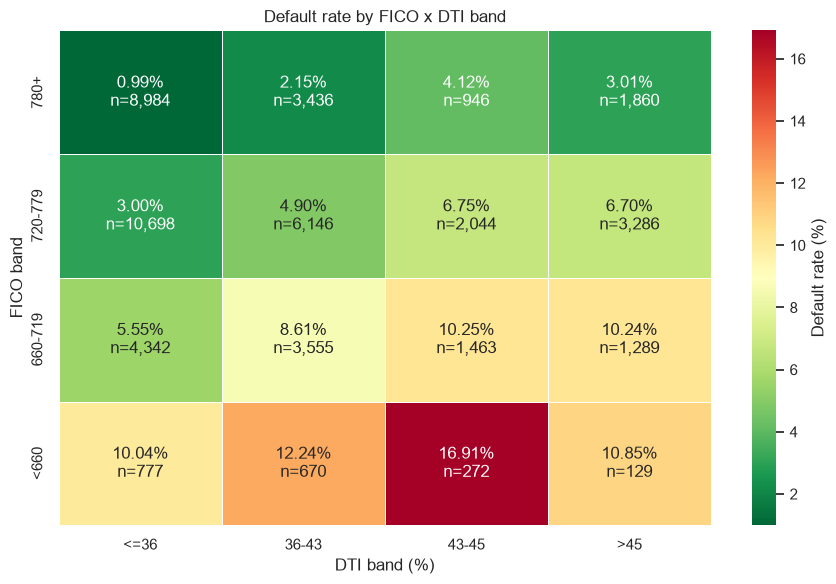

In [22]:
# Restrict to loans with both FICO and DTI populated
loans_fd = loans.dropna(subset=["credit_score", "dti"]).copy()
n_excluded = len(loans) - len(loans_fd)

# Coarser DTI banding for the heatmap
dti_bins_coarse = [-np.inf, 36, 43, 45, np.inf]
dti_labels_coarse = ["<=36", "36-43", "43-45", ">45"]

loans_fd["fico_band_c"] = pd.cut(loans_fd["credit_score"], bins=fico_bins_coarse, labels=fico_labels_coarse)
loans_fd["dti_band_c"] = pd.cut(loans_fd["dti"], bins=dti_bins_coarse, labels=dti_labels_coarse)

grid_rate = loans_fd.pivot_table(
    index="fico_band_c", columns="dti_band_c", values="default_24m", aggfunc="mean", observed=True,
) * 100
grid_count = loans_fd.pivot_table(
    index="fico_band_c", columns="dti_band_c", values="default_24m", aggfunc="size", observed=True,
)

# Same orientation as 4.1: top-left = safest, bottom-right = riskiest
grid_rate = grid_rate.reindex(index=fico_labels_coarse[::-1], columns=dti_labels_coarse)
grid_count = grid_count.reindex(index=fico_labels_coarse[::-1], columns=dti_labels_coarse)

print(f"Loans excluded (missing FICO or DTI): {n_excluded}")
print("\nDefault rate (%) by FICO x DTI band:")
print(grid_rate.round(2))
print("\nLoan count by FICO x DTI band:")
print(grid_count)

# Same annotation format as 4.1
annot = grid_rate.copy().astype(object)
for i in range(grid_rate.shape[0]):
    for j in range(grid_rate.shape[1]):
        rate = grid_rate.iat[i, j]
        cnt = grid_count.iat[i, j]
        annot.iat[i, j] = f"{rate:.2f}%\nn={cnt:,}" if pd.notna(rate) else "—"

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    grid_rate, annot=annot, fmt="", cmap="RdYlGn_r",
    cbar_kws={"label": "Default rate (%)"},
    linewidths=0.5, linecolor="white",
    ax=ax,
)
ax.set_title("Default rate by FICO x DTI band")
ax.set_xlabel("DTI band (%)")
ax.set_ylabel("FICO band")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_bivariate_fico_dti.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway.** FICO remains ordered within every DTI band, while DTI peaks around 43–45% and falls above 45%. This repeated descriptive reversal is compatible with selection effects, but reserves and other compensating factors are not observed here. The pattern supports testing flexible DTI effects; it does not by itself dictate a particular model.

### 4.3 LTV x DTI

Loans excluded (missing LTV or DTI): 31

Default rate (%) by LTV x DTI band:
dti_band_c  <=36  36-43  43-45  >45
ltv_band_c                         
<=70        2.17   3.99   6.44 5.24
70-80       2.70   4.95   6.41 6.74
80-95       3.91   6.79   9.79 7.54
>95         5.19   8.47  12.43 6.02

Loan count by LTV x DTI band:
dti_band_c  <=36  36-43  43-45   >45
ltv_band_c                          
<=70        7739   3335   1212  2214
70-80       9696   5194   1733  2596
80-95       6492   4406   1420  1672
>95          887    874    362    83


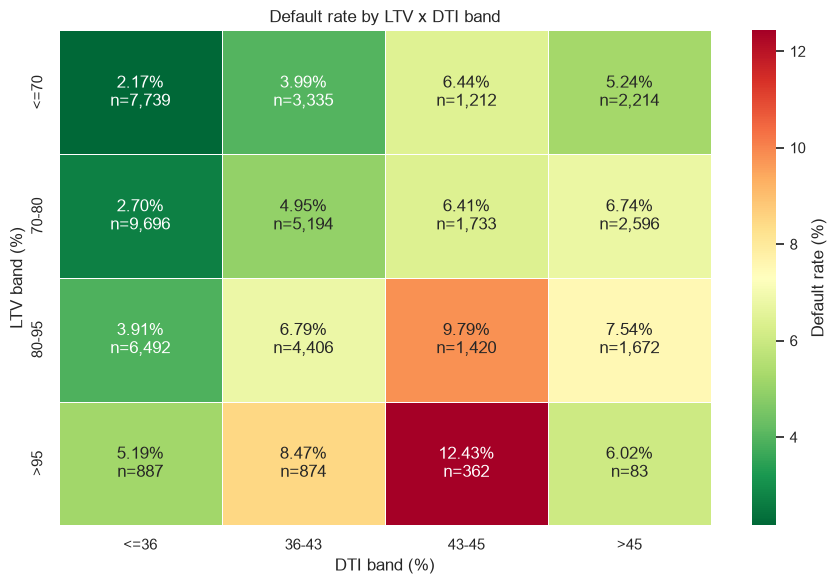

In [23]:
# Restrict to loans with both LTV and DTI populated
loans_ld = loans.dropna(subset=["ltv", "dti"]).copy()
n_excluded = len(loans) - len(loans_ld)

loans_ld["ltv_band_c"] = pd.cut(loans_ld["ltv"], bins=ltv_bins_coarse, labels=ltv_labels_coarse)
loans_ld["dti_band_c"] = pd.cut(loans_ld["dti"], bins=dti_bins_coarse, labels=dti_labels_coarse)

grid_rate = loans_ld.pivot_table(
    index="ltv_band_c", columns="dti_band_c", values="default_24m", aggfunc="mean", observed=True,
) * 100
grid_count = loans_ld.pivot_table(
    index="ltv_band_c", columns="dti_band_c", values="default_24m", aggfunc="size", observed=True,
)

# Orientation: top-left = safest (low LTV, low DTI), bottom-right = riskiest (high LTV, high DTI)
# LTV goes top to bottom = low to high, so no reindex reversal needed on LTV
grid_rate = grid_rate.reindex(index=ltv_labels_coarse, columns=dti_labels_coarse)
grid_count = grid_count.reindex(index=ltv_labels_coarse, columns=dti_labels_coarse)

print(f"Loans excluded (missing LTV or DTI): {n_excluded}")
print("\nDefault rate (%) by LTV x DTI band:")
print(grid_rate.round(2))
print("\nLoan count by LTV x DTI band:")
print(grid_count)

annot = grid_rate.copy().astype(object)
for i in range(grid_rate.shape[0]):
    for j in range(grid_rate.shape[1]):
        rate = grid_rate.iat[i, j]
        cnt = grid_count.iat[i, j]
        annot.iat[i, j] = f"{rate:.2f}%\nn={cnt:,}" if pd.notna(rate) else "—"

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    grid_rate, annot=annot, fmt="", cmap="RdYlGn_r",
    cbar_kws={"label": "Default rate (%)"},
    linewidths=0.5, linecolor="white",
    ax=ax,
)
ax.set_title("Default rate by LTV x DTI band")
ax.set_xlabel("DTI band (%)")
ax.set_ylabel("LTV band (%)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_bivariate_ltv_dti.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway.** Higher LTV is associated with higher observed rates within each DTI band. The DTI reversal also persists in this grid, although the extreme `>95 × >45` cell contains only 83 loans. These patterns motivate comparing explicit interactions with a flexible challenger model; claims about non-additivity require an actual additive benchmark.

## 5. Geographic analysis

Geography enters credit risk through three main channels: local labor markets that drive borrower income stability, house price dynamics that determine collateral value, and exposure to natural disasters that can trigger sudden defaults. This section profiles the 2019 vintage geographically, first at the state level to identify the specific outliers, then aggregated to census regions to smooth the noise that state-level analysis introduces on small states.

### 5.1 Loan volume by state

In [24]:
# Aggregate: volume by state
state_volume = (
    loans.groupby("property_state")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

# Territories vs states
US_STATES_DC = {
    "AL","AK","AZ","AR","CA","CO","CT","DE","DC","FL","GA","HI","ID","IL","IN","IA",
    "KS","KY","LA","ME","MD","MA","MI","MN","MS","MO","MT","NE","NV","NH","NJ","NM",
    "NY","NC","ND","OH","OK","OR","PA","RI","SC","SD","TN","TX","UT","VT","VA","WA",
    "WV","WI","WY",
}
territories_df = state_volume[~state_volume["property_state"].isin(US_STATES_DC)]
state_volume_map = state_volume[state_volume["property_state"].isin(US_STATES_DC)]

print(f"States + DC covered: {len(state_volume_map)}")
print(f"Territories excluded from map: {list(territories_df['property_state'])} "
      f"(total: {territories_df['count'].sum()} loans)")

print("\nTop 10 states by volume:")
print(state_volume_map.head(10).to_string(index=False))

# Choropleth
fig = px.choropleth(
    state_volume_map,
    locations="property_state",
    locationmode="USA-states",
    color="count",
    scope="usa",
    color_continuous_scale="Blues",
    labels={"count": "Loans"},
    title="Loan volume by state (2019 vintage sample)",
)
fig.update_layout(
    geo=dict(bgcolor="rgba(0,0,0,0)"),
    margin=dict(l=10, r=10, t=50, b=10),
    coloraxis_colorbar=dict(title="Loans"),
)

# Static PNG export
out_path = FIGURES_DIR / "02_geographic_volume.png"
try:
    fig.write_image(str(out_path), width=1000, height=600, scale=2)
    print(f"Saved static figure: {out_path.relative_to(PROJECT_ROOT)}")
except Exception as exc:
    print(f"Static PNG export skipped: {type(exc).__name__}")
fig.show()

States + DC covered: 51
Territories excluded from map: ['PR', 'GU', 'VI'] (total: 14 loans)

Top 10 states by volume:
property_state  count
            CA   5897
            TX   3822
            FL   3275
            IL   2227
            AZ   1893
            MI   1842
            OH   1827
            CO   1648
            GA   1581
            WA   1556
Saved static figure: figures/02_geographic_volume.png


**Takeaway.** The sample is geographically concentrated, with California, Texas, and Florida carrying the largest counts. The map describes exposure in the supplied sample. Links to natural hazards, industry mix, or housing-market structure are plausible external hypotheses, not variables tested in this dataset.

### 5.2 Default rate by state

In [25]:
state_base = loans[loans["property_state"].isin(US_STATES_DC)]
state_stats = binomial_summary(state_base, "property_state").reset_index()
state_stats["default_rate_pct"] = state_stats["default_rate"] * 100

print("Top 10 states by default rate (all volumes):")
print(state_stats.sort_values("default_rate", ascending=False).head(10).to_string(index=False))

reliable_states = state_stats[state_stats["count"] >= 500]
print("\nTop states with >=500 loans:")
print(reliable_states.sort_values("default_rate", ascending=False).head(10).to_string(index=False))

fig = px.choropleth(
    state_stats,
    locations="property_state",
    locationmode="USA-states",
    color="default_rate_pct",
    scope="usa",
    color_continuous_scale="RdYlGn_r",
    range_color=(2, 8),
    labels={"default_rate_pct": "Default rate (%)"},
    title="Observed default rate by state — sample view",
)
fig.update_layout(
    geo=dict(bgcolor="rgba(0,0,0,0)"),
    margin=dict(l=10, r=10, t=50, b=10),
    coloraxis_colorbar=dict(title="Default rate (%)"),
)
out_path = FIGURES_DIR / "02_geographic_default_rate.png"
try:
    fig.write_image(str(out_path), width=1000, height=600, scale=2)
    print(f"Saved static figure: {out_path.relative_to(PROJECT_ROOT)}")
except Exception as exc:
    print(f"Static PNG export skipped: {type(exc).__name__}")
fig.show()

Top 10 states by default rate (all volumes):
property_state  count  defaults  default_rate  ci_low  ci_high  default_rate_pct
            VT    105         9          0.09    0.05     0.15              8.57
            NJ   1279       103          0.08    0.07     0.10              8.05
            NY   1443       113          0.08    0.07     0.09              7.83
            HI    132        10          0.08    0.04     0.13              7.58
            CT    445        33          0.07    0.05     0.10              7.42
            LA    418        30          0.07    0.05     0.10              7.18
            FL   3275       224          0.07    0.06     0.08              6.84
            DC    105         7          0.07    0.03     0.13              6.67
            ND     84         5          0.06    0.03     0.13              5.95
            NV    726        42          0.06    0.04     0.08              5.79

Top states with >=500 loans:
property_state  count  defaults  d

**Takeaway.** New Jersey, New York, and Florida have elevated observed rates among states with at least 500 sampled loans, while several Midwest states are lower. Confidence intervals and volume restrictions reduce, but do not remove, geographic noise. State effects may proxy for borrower mix, housing costs, labor markets, servicing, or unobserved variables; policy conclusions require adjusted analysis and external validation.

### 5.3 Average loan size

In [26]:
upb_by_state = (
    loans[loans["property_state"].isin(US_STATES_DC)]
    .groupby("property_state")
    .agg(count=("default_24m", "size"), avg_upb=("original_upb", "mean"))
    .reset_index()
)
upb_by_state["avg_upb_k"] = upb_by_state["avg_upb"] / 1e3

state_upb_risk = upb_by_state.merge(
    state_stats[["property_state", "default_rate"]], on="property_state", validate="one_to_one"
)
unweighted_corr = state_upb_risk["avg_upb"].corr(state_upb_risk["default_rate"])

def weighted_corr(x, y, w):
    x_bar = np.average(x, weights=w)
    y_bar = np.average(y, weights=w)
    cov = np.average((x - x_bar) * (y - y_bar), weights=w)
    return cov / np.sqrt(
        np.average((x - x_bar) ** 2, weights=w)
        * np.average((y - y_bar) ** 2, weights=w)
    )

volume_weighted_corr = weighted_corr(
    state_upb_risk["avg_upb"], state_upb_risk["default_rate"], state_upb_risk["count"]
)
print(f"Unweighted state-level correlation: {unweighted_corr:.3f}")
print(f"Volume-weighted state-level correlation: {volume_weighted_corr:.3f}")

fig = px.choropleth(
    upb_by_state,
    locations="property_state",
    locationmode="USA-states",
    color="avg_upb_k",
    scope="usa",
    color_continuous_scale="Blues",
    labels={"avg_upb_k": "Avg UPB ($k)"},
    title="Average original UPB by state — sample view",
)
fig.update_layout(
    geo=dict(bgcolor="rgba(0,0,0,0)"),
    margin=dict(l=10, r=10, t=50, b=10),
    coloraxis_colorbar=dict(title="Avg UPB ($k)"),
)
out_path = FIGURES_DIR / "02_geographic_avg_upb.png"
try:
    fig.write_image(str(out_path), width=1000, height=600, scale=2)
    print(f"Saved static figure: {out_path.relative_to(PROJECT_ROOT)}")
except Exception as exc:
    print(f"Static PNG export skipped: {type(exc).__name__}")
fig.show()

Unweighted state-level correlation: 0.432
Volume-weighted state-level correlation: 0.300
Saved static figure: figures/02_geographic_avg_upb.png


**Takeaway.** Average balance varies substantially by state, but the relationship with default must be read from the correlations computed above rather than inferred visually. Even a state-level correlation would be ecological: it does not imply that a larger individual loan causes higher default risk. Borrower-level adjustment is required.

### 5.4 Aggregation to census regions

Regional aggregation:
            count  defaults default_rate  ci_low  ci_high
region                                                   
Northeast   6,398       381       5.95 %    0.05     0.07
Midwest    11,463       398       3.47 %    0.03     0.04
South      17,225       854       4.96 %    0.05     0.05
West       14,846       657       4.43 %    0.04     0.05


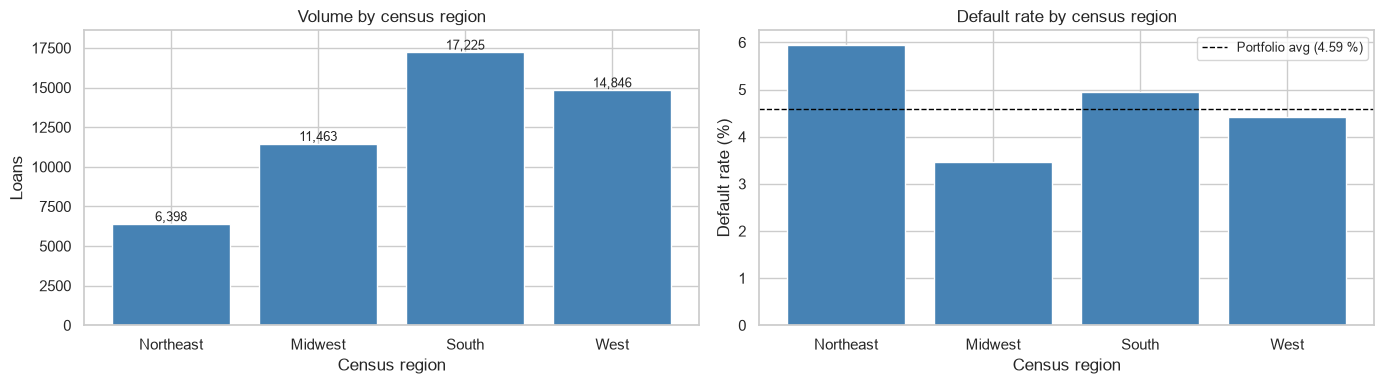

In [27]:
CENSUS_REGIONS = {
    "Northeast": {"CT", "ME", "MA", "NH", "NJ", "NY", "PA", "RI", "VT"},
    "Midwest":   {"IL", "IN", "IA", "KS", "MI", "MN", "MO", "NE", "ND", "OH", "SD", "WI"},
    "South":     {"AL", "AR", "DE", "DC", "FL", "GA", "KY", "LA", "MD", "MS", "NC",
                  "OK", "SC", "TN", "TX", "VA", "WV"},
    "West":      {"AK", "AZ", "CA", "CO", "HI", "ID", "MT", "NV", "NM", "OR", "UT",
                  "WA", "WY"},
}

# Reverse map: state -> region
STATE_TO_REGION = {state: region for region, states in CENSUS_REGIONS.items() for state in states}

# Sanity: verify all 51 US states are covered
covered = set(STATE_TO_REGION.keys())
assert covered == US_STATES_DC, f"Region mapping mismatch: {US_STATES_DC - covered} missing, {covered - US_STATES_DC} extra"

# Aggregate
region_data = loans[loans["property_state"].isin(US_STATES_DC)].assign(
    region=lambda d: d["property_state"].map(STATE_TO_REGION)
)
region_stats = binomial_summary(region_data, "region").reindex(
    ["Northeast", "Midwest", "South", "West"]
)

print("Regional aggregation:")
print(region_stats.assign(
    count=lambda d: d["count"].map("{:,}".format),
    default_rate=lambda d: (d["default_rate"] * 100).map("{:.2f} %".format),
))

# Figure
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(region_stats.index, region_stats["count"], color="steelblue")
axes[0].set_title("Volume by census region")
axes[0].set_xlabel("Census region")
axes[0].set_ylabel("Loans")
for i, v in enumerate(region_stats["count"]):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
axes[0].set_ylim(0, region_stats["count"].max() * 1.08)

axes[1].bar(region_stats.index, region_stats["default_rate"] * 100, color="steelblue")
axes[1].axhline(default_rate * 100, color="black", linestyle="--", linewidth=1,
                label=f"Portfolio avg ({default_rate * 100:.2f} %)")
axes[1].set_title("Default rate by census region")
axes[1].set_xlabel("Census region")
axes[1].set_ylabel("Default rate (%)")
axes[1].legend(loc="upper right", fontsize=9)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_geographic_region.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway.** Regional aggregation produces more stable descriptive estimates than small-state rates. The Northeast is highest and the Midwest lowest in this sample, but region remains a composite proxy. Region and state encodings should be compared under cross-validation, with rare categories regularized.

## 6. Temporal analysis

So far every view has aggregated across the whole vintage. This section asks whether the 2019 book is homogeneous over time or whether specific origination cohorts behave differently. Two questions matter: whether default rates drift across the year (a vintage effect within 2019 itself, which could reflect underwriting drift or macro shifts), and whether prepayment behavior varies by cohort in a way that shapes the observation window we saw in section 2.2.

### 6.1 Default rate by origination quarter

First-payment quarter statistics:
                        count  defaults default_rate  ci_low  ci_high
first_payment_quarter                                                
2019Q1                  3,475       175       5.04 %    0.04     0.06
2019Q2                 12,854       589       4.58 %    0.04     0.05
2019Q3                 12,473       544       4.36 %    0.04     0.05
2019Q4                 13,212       642       4.86 %    0.05     0.05
2020Q1                  7,932       342       4.31 %    0.04     0.05

Note: 2019Q1 is partial because the sample starts in February 2019.


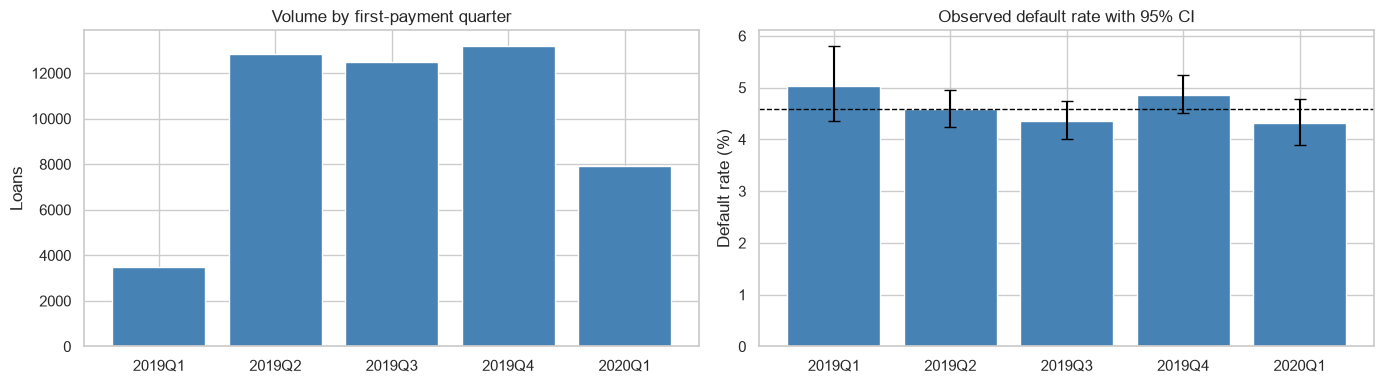

In [28]:
fpd = pd.to_datetime(loans["first_payment_date"].astype(str), format="%Y%m")
loans_time = loans.assign(
    fpd=fpd,
    first_payment_quarter=fpd.dt.to_period("Q").astype(str),
)

quarter_stats = binomial_summary(
    loans_time, "first_payment_quarter"
).sort_index()

print("First-payment quarter statistics:")
print(quarter_stats.assign(
    count=lambda d: d["count"].map("{:,}".format),
    default_rate=lambda d: (d["default_rate"] * 100).map("{:.2f} %".format),
)[["count", "defaults", "default_rate", "ci_low", "ci_high"]])
print("\nNote: 2019Q1 is partial because the sample starts in February 2019.")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(quarter_stats.index, quarter_stats["count"], color="steelblue")
axes[0].set_title("Volume by first-payment quarter")
axes[0].set_ylabel("Loans")

axes[1].bar(quarter_stats.index, quarter_stats["default_rate"] * 100, color="steelblue")
axes[1].errorbar(
    quarter_stats.index,
    quarter_stats["default_rate"] * 100,
    yerr=[
        (quarter_stats["default_rate"] - quarter_stats["ci_low"]) * 100,
        (quarter_stats["ci_high"] - quarter_stats["default_rate"]) * 100,
    ], fmt="none", color="black", capsize=4,
)
axes[1].axhline(default_rate * 100, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Observed default rate with 95% CI")
axes[1].set_ylabel("Default rate (%)")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_temporal_default_by_quarter.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway.** Observed rates vary modestly across first-payment cohorts, with overlapping uncertainty for several quarters. This does not demonstrate constant underwriting quality because cohorts experienced different calendar exposure to COVID and 2019Q1 is incomplete. Cohort should be considered in temporal validation even if it is not retained as a borrower feature.

### 6.2 Observation window by cohort

Observation window by origination cohort:
                        count avg_obs_months pct_full_obs
first_payment_quarter                                    
2019Q1                  3,475           19.6       44.1 %
2019Q2                 12,854           19.6       43.3 %
2019Q3                 12,473           19.7       45.1 %
2019Q4                 13,212           20.1       47.5 %
2020Q1                  7,932           19.8       48.0 %


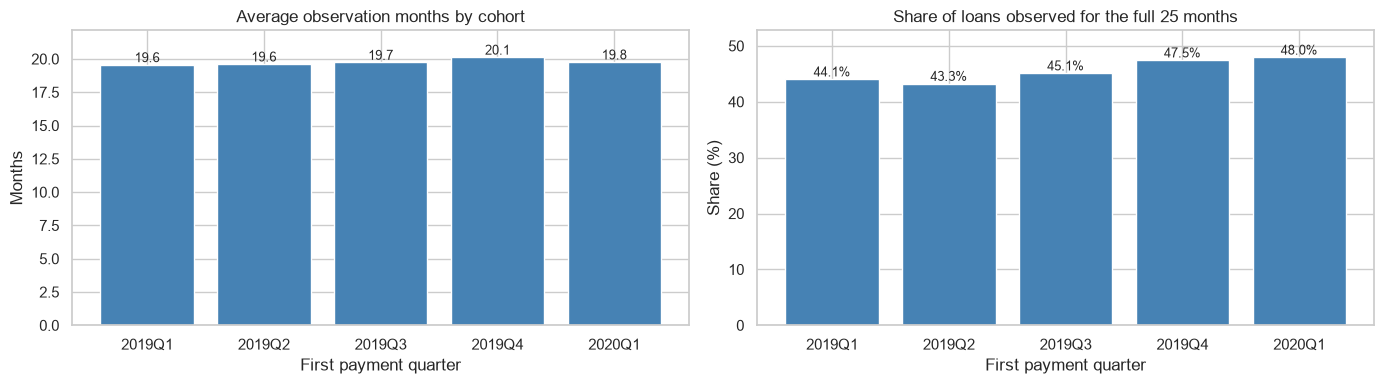

In [29]:
# Reuse the quarter assignment from 6.1
# Aggregate: for each cohort, count, avg observation window, and share reaching 25 months
cohort_obs = (
    loans_time.groupby("first_payment_quarter")
    .agg(
        count=("default_24m", "size"),
        avg_obs_months=("observation_months", "mean"),
        pct_full_obs=("observation_months", lambda s: (s == 25).mean()),
    )
    .sort_index()
)

# Filter quarters with sufficient volume (consistent with 6.1)
cohort_obs_clean = cohort_obs[cohort_obs["count"] >= 500]

print("Observation window by origination cohort:")
print(cohort_obs_clean.assign(
    count=lambda d: d["count"].map("{:,}".format),
    avg_obs_months=lambda d: d["avg_obs_months"].map("{:.1f}".format),
    pct_full_obs=lambda d: (d["pct_full_obs"] * 100).map("{:.1f} %".format),
))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: average observation months per cohort
axes[0].bar(cohort_obs_clean.index, cohort_obs_clean["avg_obs_months"], color="steelblue")
axes[0].set_title("Average observation months by cohort")
axes[0].set_xlabel("First payment quarter")
axes[0].set_ylabel("Months")
for i, v in enumerate(cohort_obs_clean["avg_obs_months"]):
    axes[0].text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)
axes[0].set_ylim(0, cohort_obs_clean["avg_obs_months"].max() * 1.10)

# Right: share of loans observed for the full 25 months (i.e. no prepayment before month 24)
axes[1].bar(cohort_obs_clean.index, cohort_obs_clean["pct_full_obs"] * 100, color="steelblue")
axes[1].set_title("Share of loans observed for the full 25 months")
axes[1].set_xlabel("First payment quarter")
axes[1].set_ylabel("Share (%)")
for i, v in enumerate(cohort_obs_clean["pct_full_obs"] * 100):
    axes[1].text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
axes[1].set_ylim(0, (cohort_obs_clean["pct_full_obs"] * 100).max() * 1.10)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_temporal_obs_by_cohort.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway.** Coverage is similar across first-payment cohorts. Because the performance file extends well beyond the 24-month horizon, shorter histories are primarily explained by terminal exits—especially voluntary payoff—not by an administrative data cutoff. Coverage is a diagnostic outcome and must not enter an origination-time model.

## 7. Loan performance dynamics

The binary target hides event timing. This section estimates a discrete monthly default hazard using the same calendar clock as notebook 01. The risk set excludes loans after payoff/end of observation and after a prior default.

In [30]:
from src.loaders import FreddieMacLoader

loader = FreddieMacLoader(DATA_RAW)
perf = loader.load_performance()
perf = perf[perf["loan_sequence_number"].isin(set(loans["loan_sequence_number"]))].copy()

fpd_by_loan = loans.set_index("loan_sequence_number")["first_payment_date"]
age_zero_by_loan = (
    pd.to_datetime(fpd_by_loan.astype(str), format="%Y%m").dt.to_period("M") - 1
)
reporting_period = pd.to_datetime(
    perf["monthly_reporting_period"].astype(str), format="%Y%m"
).dt.to_period("M")
expected_age_zero = perf["loan_sequence_number"].map(age_zero_by_loan)
perf["months_since_start"] = (
    reporting_period.astype("int64") - expected_age_zero.astype("int64")
)
perf = perf[perf["months_since_start"].between(0, 24)].copy()
perf["dpd"] = pd.to_numeric(perf["current_loan_delinquency_status"], errors="coerce")

assert perf["dpd"].notna().all()
assert perf["months_since_start"].between(0, 24).all()

print(f"Calendar-corrected performance table: {len(perf):,} rows")
print(f"Distinct loans: {perf['loan_sequence_number'].nunique():,}")
print(f"Calendar month range: {perf['months_since_start'].min()} to {perf['months_since_start'].max()}")

Calendar-corrected performance table: 988,761 rows
Distinct loans: 49,946
Calendar month range: 0 to 24


In [31]:
dpd_hits = perf[perf["dpd"] >= 3]
first_default_age = (
    dpd_hits.groupby("loan_sequence_number")["months_since_start"]
    .min()
    .rename("first_default_age")
)

print(f"Loans reaching 90+ DPD: {len(first_default_age):,}")
print(f"Cross-check with target: {int(loans['default_24m'].sum()):,}")
assert len(first_default_age) == int(loans["default_24m"].sum())
print(first_default_age.describe(percentiles=[0.25, 0.5, 0.75, 0.9]).round(2))

Loans reaching 90+ DPD: 2,292
Cross-check with target: 2,292
count   2292.00
mean      12.49
std        4.54
min        3.00
25%        9.00
50%       12.00
75%       16.00
90%       19.00
max       24.00
Name: first_default_age, dtype: float64


In [32]:
observation_bounds = perf.groupby("loan_sequence_number")["months_since_start"].agg(
    first_observed="min", last_observed="max"
)
risk_data = observation_bounds.join(first_default_age, how="left")

ages = np.arange(0, 25)
at_risk = np.zeros(len(ages), dtype=int)
new_defaults = np.zeros(len(ages), dtype=int)

for i, t in enumerate(ages):
    eligible = (
        (risk_data["first_observed"] <= t)
        & (risk_data["last_observed"] >= t)
        & (risk_data["first_default_age"].isna() | (risk_data["first_default_age"] >= t))
    )
    at_risk[i] = int(eligible.sum())
    new_defaults[i] = int((risk_data["first_default_age"] == t).sum())

hazard = np.divide(
    new_defaults, at_risk,
    out=np.zeros_like(new_defaults, dtype=float),
    where=at_risk > 0,
)
cumulative_share_of_defaults = np.cumsum(new_defaults) / new_defaults.sum() * 100

hazard_df = pd.DataFrame({
    "loan_age": ages,
    "at_risk": at_risk,
    "new_defaults": new_defaults,
    "hazard_rate_pct": hazard * 100,
    "cumulative_pct_of_defaults": cumulative_share_of_defaults,
})

print(hazard_df.round(3).to_string(index=False))

 loan_age  at_risk  new_defaults  hazard_rate_pct  cumulative_pct_of_defaults
        0    45721             0             0.00                        0.00
        1    48560             0             0.00                        0.00
        2    49431             0             0.00                        0.00
        3    49515            19             0.04                        0.83
        4    49381            14             0.03                        1.44
        5    49114            77             0.16                        4.80
        6    48503            89             0.18                        8.68
        7    47498           151             0.32                       15.27
        8    46272           163             0.35                       22.38
        9    44920           161             0.36                       29.41
       10    43581           156             0.36                       36.21
       11    42040           164             0.39               

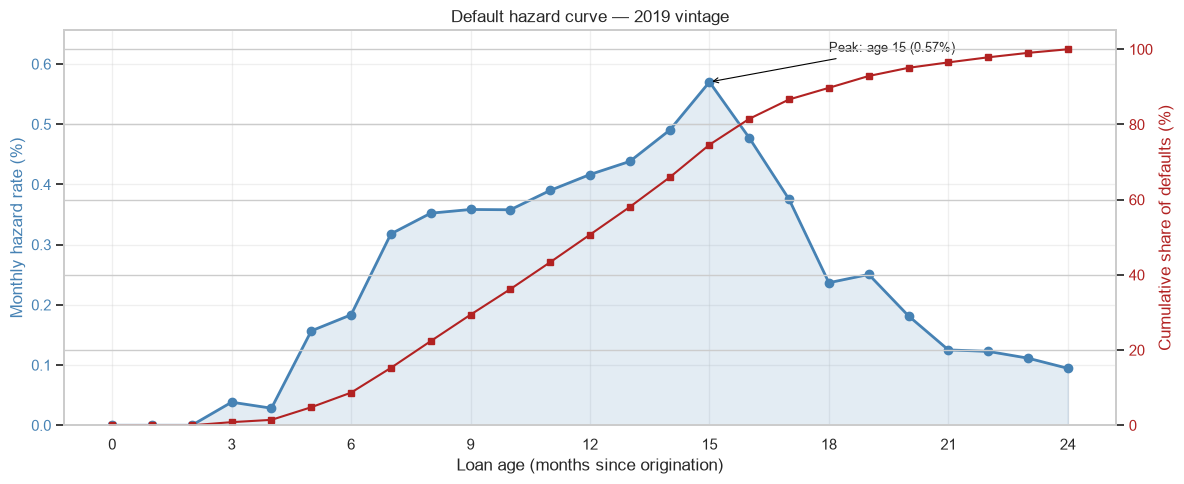

In [33]:
fig, ax1 = plt.subplots(figsize=(12, 5))

# Hazard rate on the primary axis
color_hazard = "steelblue"
ax1.plot(hazard_df["loan_age"], hazard_df["hazard_rate_pct"],
         marker="o", color=color_hazard, linewidth=2, label="Hazard rate")
ax1.fill_between(hazard_df["loan_age"], hazard_df["hazard_rate_pct"],
                 alpha=0.15, color=color_hazard)
ax1.set_xlabel("Loan age (months since origination)")
ax1.set_ylabel("Monthly hazard rate (%)", color=color_hazard)
ax1.tick_params(axis="y", labelcolor=color_hazard)
ax1.set_ylim(0, hazard_df["hazard_rate_pct"].max() * 1.15)
ax1.set_xticks(range(0, 25, 3))

# Cumulative defaults on the secondary axis
ax2 = ax1.twinx()
color_cum = "firebrick"
ax2.plot(hazard_df["loan_age"], hazard_df["cumulative_pct_of_defaults"],
         marker="s", markersize=5, color=color_cum, linewidth=1.5, label="Cumulative")
ax2.set_ylabel("Cumulative share of defaults (%)", color=color_cum)
ax2.tick_params(axis="y", labelcolor=color_cum)
ax2.set_ylim(0, 105)

# Annotation for the peak
peak_age = hazard_df.loc[hazard_df["hazard_rate_pct"].idxmax(), "loan_age"]
peak_val = hazard_df["hazard_rate_pct"].max()
ax1.annotate(
    f"Peak: age {peak_age} ({peak_val:.2f}%)",
    xy=(peak_age, peak_val),
    xytext=(peak_age + 3, peak_val + 0.05),
    fontsize=9,
    arrowprops=dict(arrowstyle="->", color="black", lw=0.8),
)

ax1.set_title("Default hazard curve — 2019 vintage")
ax1.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_performance_hazard_curve.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway.** The risk set grows during the first few months because some loans begin reporting late. After accounting for this delayed entry, the calendar correction, and prior defaults, the monthly hazard peaks around month 15 at roughly 0.57%. The concentration of events around the pandemic period is descriptively consistent with a macro shock, but this curve alone cannot separate unemployment effects, borrower assistance, servicing practices, or natural seasoning. It should not be interpreted as evidence that forbearance suppressed delinquency reporting.

## 8. Sensitivity and interpretation of the label

The target is a recorded-delinquency endpoint, not realized credit loss. This section tests sensitivity to alternative DPD thresholds and compares outcomes by coverage and exit status. It does not attempt to identify forbearance because the required borrower-assistance fields are not loaded.

### 8.1 What the target measures

`default_24m` records whether the servicer-reported delinquency status reaches 90+ DPD during calendar months 0–24. In SFLLD, delinquency is based on the due date of the last paid installment. This differs from credit-bureau accommodation rules and from ultimate economic loss.

Borrower assistance, cures, modifications, prepayment, foreclosure moratoria, and liquidation timing can all affect the path after delinquency. A causal forbearance analysis requires the modification, disaster, borrower-assistance, and DDLPI fields; exit codes alone cannot identify it.

### 8.2 Threshold, coverage, and exit-status sensitivity

In [34]:
max_dpd = perf.groupby("loan_sequence_number")["dpd"].max()

threshold_summary = pd.DataFrame([
    {
        "threshold": label,
        "n_loans": int((max_dpd >= cutoff).sum()),
        "rate_pct": (max_dpd >= cutoff).mean() * 100,
    }
    for cutoff, label in [(2, "60+ DPD"), (3, "90+ DPD"), (4, "120+ DPD"), (6, "180+ DPD")]
])
print("Sensitivity to delinquency threshold:")
print(threshold_summary.to_string(index=False, formatters={"rate_pct": "{:.2f}".format}))

ZB_LABELS = {
    "01": "Prepaid / matured",
    "02": "Third-party sale",
    "03": "Short sale / charge-off",
    "06": "Repurchase",
    "09": "REO disposition",
    "15": "Note sale",
    "16": "Reperforming loan sale",
    "96": "Removed after defect",
    "97": "Delinquent servicing transfer",
    "98": "Other transfer",
}

last_zb = (
    perf.sort_values(["loan_sequence_number", "monthly_reporting_period"])
    .groupby("loan_sequence_number")["zero_balance_code"]
    .last()
)
exit_status = last_zb.map(ZB_LABELS).fillna("No zero-balance code in horizon")
exit_frame = loans[["loan_sequence_number", "default_24m"]].merge(
    exit_status.rename("exit_status").reset_index(),
    on="loan_sequence_number", how="left", validate="one_to_one",
)
exit_stats = binomial_summary(exit_frame, "exit_status").sort_values("count", ascending=False)
print("\nObserved target by exit status:")
exit_display = exit_stats.assign(
    default_rate_pct=exit_stats["default_rate"] * 100,
    ci_95_pct=[f"[{lo*100:.2f}, {hi*100:.2f}]" for lo, hi in zip(exit_stats.ci_low, exit_stats.ci_high)],
)
print(exit_display[["count", "defaults", "default_rate_pct", "ci_95_pct"]].to_string(
    formatters={"default_rate_pct": "{:.2f}".format}
))

coverage_frame = loans.assign(
    coverage_band=pd.cut(
        loans["observation_months"],
        bins=[0, 11, 17, 24, 25],
        labels=["1-11", "12-17", "18-24", "25"],
    )
)
coverage_stats = binomial_summary(coverage_frame, "coverage_band")
print("\nObserved target by number of reporting months:")
coverage_display = coverage_stats.assign(
    default_rate_pct=coverage_stats["default_rate"] * 100,
    ci_95_pct=[f"[{lo*100:.2f}, {hi*100:.2f}]" for lo, hi in zip(coverage_stats.ci_low, coverage_stats.ci_high)],
)
print(coverage_display[["count", "defaults", "default_rate_pct", "ci_95_pct"]].to_string(
    formatters={"default_rate_pct": "{:.2f}".format}
))

Sensitivity to delinquency threshold:
threshold  n_loans rate_pct
  60+ DPD     2829     5.66
  90+ DPD     2292     4.59
 120+ DPD     1865     3.73
 180+ DPD     1342     2.69

Observed target by exit status:
                                 count  defaults default_rate_pct        ci_95_pct
exit_status                                                                       
Prepaid / matured                25743       503             1.95     [1.79, 2.13]
No zero-balance code in horizon  24097      1780             7.39     [7.06, 7.72]
Removed after defect               105         8             7.62    [3.91, 14.32]
Short sale / charge-off              1         1           100.00  [20.65, 100.00]

Observed target by number of reporting months:
               count  defaults default_rate_pct     ci_95_pct
coverage_band                                                
1-11            7307        25             0.34  [0.23, 0.50]
12-17           9631       114             1.18  [0.99, 1

**Takeaway.** Target prevalence changes materially with the DPD threshold, as expected. Loans with a voluntary payoff have lower observed default incidence because payoff terminates exposure, while loans remaining active or exiting through distressed paths are higher. Coverage groups are outcome-dependent and therefore diagnostic—not candidate predictors. None of these tables identifies forbearance participation.

### 8.3 Modelling implications and limitations

The model in notebook 03 should predict the observed 90+ DPD endpoint using origination-time information only. Its discrimination and calibration must be evaluated separately; neither can be assumed to transfer unchanged to later vintages or different policy environments.

Recommended safeguards are temporal or multi-vintage validation, explicit probability calibration, and a clear distinction between predicted delinquency, foreclosure, and realized loss. A future causal analysis of pandemic assistance requires loading the relevant performance fields rather than inferring assistance from liquidation codes.

## 9. Synthesis and modelling hypotheses

The EDA identifies candidate predictors and interactions, but final feature selection and interpretation belong to cross-validated modelling. All post-origination diagnostics remain excluded from the modelling table.

### 9.1 First-order candidates

- **FICO**: strongest ordered univariate gradient among the examined variables.
- **LTV**: consistent increasing gradient across the selected bands.
- **DTI**: strong but non-monotonic descriptive association.

FICO × LTV and the flexible shape of DTI are interaction/non-linearity hypotheses to test against an additive baseline, not conclusions that predetermine the winning model.

### 9.2 Secondary candidates

First-time buyer status, borrower count, number of units, purpose, property type, channel, occupancy, and geography all show varying descriptive spreads. Their incremental value must be assessed after adjustment for FICO, LTV, and DTI, with pooling or regularization for sparse levels.

### 9.3 Features excluded from prediction

- `loan_sequence_number`: identifier only.
- `max_dpd_24m`: directly determines the target.
- `observation_months`, `last_reporting_period_24m`, `prepaid_within_24m`: post-origination outcomes.
- raw performance and exit-status fields: unavailable at application time.

First-payment cohort may be used for validation design, but should not silently substitute for a robust out-of-time test.

### 9.4 Model comparison implied by the EDA

Notebook 03 should compare:

1. an interpretable logistic-regression baseline with controlled transformations and explicit interactions;
2. a gradient-boosting challenger able to learn non-linearities and interactions;
3. calibration and discrimination metrics evaluated out of sample and, ideally, out of time.

The gradient-boosting model is a candidate, not a foregone conclusion. Feature lists must be explicit so that no diagnostic or post-origination field can enter training.